# Регуляризація та функції активації в нейронних мережах

## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.
## Завдання 1
Дослідіть вплив функцій активації на результати моделі.
- Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
- Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
- Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
- Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
- Оформіть результати в таблиці:

|Активація|MAE|R²|
|-|-|-|
|ReLU|...|..|
|Tanh|...|...
|LeakyReLU|...|...|
|Swish|...|...|

In [14]:
# підготовка даних:
# 1. Генерація
from sklearn.datasets import make_regression
X,y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
# 2. Поділ на навчальну та тестову групи
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2)
# 3. Нормалізація (масштабування)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)
# 4. Перетворення на тензори, з якими працює нейромережа
import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest = torch.tensor(xtest, dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1) * 0.01  # ручне масштабування
ytest = torch.tensor(ytest, dtype=torch.float32).reshape(-1,1) * 0.01    # без нього не всі моделі навчаються
xtrain[:5]

tensor([[ 0.4732, -0.4410, -1.7118, -2.5808,  1.0533, -0.7579,  0.1095, -0.4893,
         -0.1014,  0.4370],
        [-1.0655,  1.7908,  1.8768, -0.0255,  0.2936, -0.9477, -0.5826, -1.5118,
         -1.0157,  2.0679],
        [-1.1210, -0.4171, -2.4705,  0.6787, -1.0626,  0.2388,  0.6443,  1.8571,
          0.1099, -0.3935],
        [ 0.5325, -0.8872,  0.4774,  0.4800, -1.2999, -2.3534, -0.3260,  0.1294,
          0.6877,  0.5732],
        [-0.2297,  0.8654,  2.0345,  0.1484, -2.3416, -1.9409,  0.3108, -0.7907,
          0.3775,  0.4934]])

In [15]:
# Готуємо різні функції активації
import torch.nn as nn
activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "SiLU": nn.SiLU(),
    "Swish": nn.SiLU(),
}

In [84]:
# Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
class Mlp(nn.Module):
    def __init__(
        self, 
        input_size=10,      # S-elements (вхідний шар) / ознаки
        hidden_size=32,     # A-elements (прихований/внутрішній шар)
        output_size=1,      # R-elements (виходи)
        activation="ReLU"   # функція активації елементів
    ):
        super(Mlp, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size),
        )

    def forward(self,x, mode = 'test') :
        return self.layers(x)
        
        

In [85]:
# Функція для навчання моделей
def train_model(model, X, y, epochs=1000, lr=0.01) :
    criterion = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(),lr=lr)
    losses = [*range(epochs)]
    for epoch in range(epochs) :
        output = model(X, 'train')   # model.forward(X)
        loss = criterion(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses[epoch] = loss.item()
    return losses    

In [86]:
# Послідовно застосуйте різні функції активації
mlps = { k: Mlp(activation=k) for k in activators.keys() }
# mlps

In [87]:
def train_models_set(mlps, xtrain, ytrain) :
    losses = {}
    predictions = {}
    for k, mlp in mlps.items() :
        losses[k] = train_model(mlp, xtrain, ytrain)  # навчаємо всі моделі та зберігаємо їх прогреси (втрати)
        with torch.no_grad() :
            predictions[k] = mlp(xtest)
    return losses, predictions


In [88]:
losses , predictions = train_models_set(mlps, xtrain, ytrain)
print(*zip(*(predictions[k][:5] for k in mlps.keys() ), ytest[:5]),sep='\n')

(tensor([0.4581]), tensor([0.2593]), tensor([0.3368]), tensor([0.3900]), tensor([0.3971]), tensor([0.4481]), tensor([0.5157]))
(tensor([0.2228]), tensor([0.0121]), tensor([0.2505]), tensor([0.4340]), tensor([0.1901]), tensor([0.1495]), tensor([0.2556]))
(tensor([0.9321]), tensor([1.1399]), tensor([1.0369]), tensor([1.0436]), tensor([0.9103]), tensor([0.8088]), tensor([0.8399]))
(tensor([1.3956]), tensor([1.4831]), tensor([1.3491]), tensor([1.5534]), tensor([1.2380]), tensor([1.4281]), tensor([1.3304]))
(tensor([1.8789]), tensor([1.8999]), tensor([1.8140]), tensor([1.7551]), tensor([1.7981]), tensor([1.7562]), tensor([1.8622]))


Без масштабування вихідних даних (у) деякі моделі не проходять навчання
Функції активації типу ReLU не обмежені, через що відбувається переповнення коефіцієнтів 


In [89]:
from IPython.display import Markdown as md
import sklearn.metrics as sm


def score_table(ytest, predictions):
    return md("\n".join((
        "|Активація|MAE|R²|",
        "|-|-|-|",
        *(f"|{k}|{sm.mean_absolute_error(ytest,v)}|{sm.r2_score(ytest,v)}|" for k,v in predictions.items())
    )))

In [90]:
# Побудувати лінії втрат (losses) на одному графіку. Назви додати як легенду
import matplotlib.pyplot as plt
def plot_losses(losses) :
    _,ax = plt.subplots()
    for k,v in losses.items() :
        ax.plot(v, label=k)
    ax.legend()    
    plt.show()

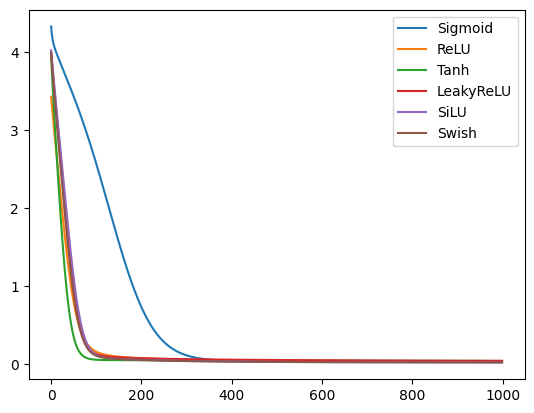

In [91]:
plot_losses(losses)

In [92]:
class MlpDropout(nn.Module):
    def __init__(
        self, 
        input_size=10,      # S-elements (вхідний шар) / ознаки
        hidden_size=32,     # A-elements (прихований/внутрішній шар)
        output_size=1,      # R-elements (виходи)
        activation="ReLU"   # функція активації елементів
    ):
        super(MlpDropout, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(hidden_size, output_size)
        

    def forward(self,x, mode='test') :
        x = self.hidden(x)
        x = self.activation(x)
        if mode != "test" :
            x = self.dropout(x)
        x = self.output(x)
        return x
        

In [93]:
mlps_d = { k: MlpDropout(activation=k) for k in activators.keys() }
losses_d , predictions_d = train_models_set(mlps_d, xtrain, ytrain)
print(*zip(*(predictions_d[k][:5] for k in mlps_d.keys() ), ytest[:5]),sep='\n')
score_table(ytest, predictions_d)

(tensor([0.4084]), tensor([0.4016]), tensor([0.4397]), tensor([0.4996]), tensor([0.4012]), tensor([0.4121]), tensor([0.5157]))
(tensor([0.2556]), tensor([0.1875]), tensor([0.2195]), tensor([0.1017]), tensor([0.1863]), tensor([0.2530]), tensor([0.2556]))
(tensor([0.8386]), tensor([0.8856]), tensor([0.9038]), tensor([0.8457]), tensor([0.8444]), tensor([0.7865]), tensor([0.8399]))
(tensor([1.3651]), tensor([1.3689]), tensor([1.4729]), tensor([1.3838]), tensor([1.4515]), tensor([1.2901]), tensor([1.3304]))
(tensor([1.7149]), tensor([1.8968]), tensor([1.6863]), tensor([1.7275]), tensor([1.7475]), tensor([1.7143]), tensor([1.8622]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.1975625455379486|0.9662308096885681|
|ReLU|0.1427113562822342|0.9902300238609314|
|Tanh|0.14294996857643127|0.9854370355606079|
|LeakyReLU|0.13521021604537964|0.9920482039451599|
|SiLU|0.11071910709142685|0.9950464367866516|
|Swish|0.11022694408893585|0.9951104521751404|

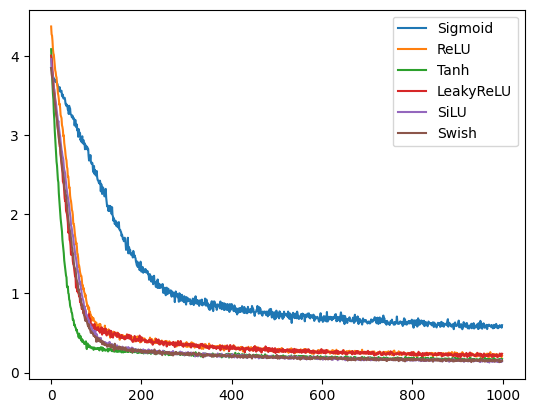

In [94]:
plot_losses(losses_d)

### Завдання 3
Додайте Batch Normalization для стабілізації навчання.
- Використовуйте шар torch.nn.BatchNorm1d після лінійного шару.
- Навчіть модель і побудуйте графік функції втрат за епохами.
- Порівняйте розкид loss з попередніми експериментами.

In [95]:
class MlpBatch(nn.Module):
    def __init__(
        self, 
        input_size=10,      # S-elements (вхідний шар) / ознаки
        hidden_size=32,     # A-elements (прихований/внутрішній шар)
        output_size=1,      # R-elements (виходи)
        activation="ReLU"   # функція активації елементів
    ):
        super(MlpBatch, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            self.activation,
        nn.Linear(hidden_size, output_size),
        )
        

    def forward(self,x, mode='test') :
        x = self.layers(x)
        return x
        

In [96]:
mlps_b = { k: MlpBatch(activation=k) for k in activators.keys() }
losses_b , predictions_b = train_models_set(mlps_b, xtrain, ytrain)
print(*zip(*(predictions_b[k][:5] for k in mlps_b.keys() ), ytest[:5]),sep='\n')
score_table(ytest, predictions_b)

(tensor([0.4933]), tensor([0.4436]), tensor([0.5292]), tensor([0.5047]), tensor([0.4876]), tensor([0.3515]), tensor([0.5157]))
(tensor([0.3115]), tensor([0.1593]), tensor([0.3255]), tensor([0.3233]), tensor([0.2586]), tensor([0.2471]), tensor([0.2556]))
(tensor([0.9917]), tensor([0.8291]), tensor([1.0272]), tensor([0.8627]), tensor([0.8830]), tensor([0.8718]), tensor([0.8399]))
(tensor([1.4740]), tensor([1.5976]), tensor([1.3357]), tensor([1.4753]), tensor([1.4965]), tensor([1.4951]), tensor([1.3304]))
(tensor([1.9629]), tensor([2.0865]), tensor([1.8892]), tensor([1.6842]), tensor([1.9446]), tensor([2.0664]), tensor([1.8622]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.16049541532993317|0.9847158193588257|
|ReLU|0.12371382862329483|0.9938026070594788|
|Tanh|0.22658248245716095|0.9730383157730103|
|LeakyReLU|0.12015661597251892|0.9939510226249695|
|SiLU|0.10085669159889221|0.9956338405609131|
|Swish|0.09932287037372589|0.9957143068313599|

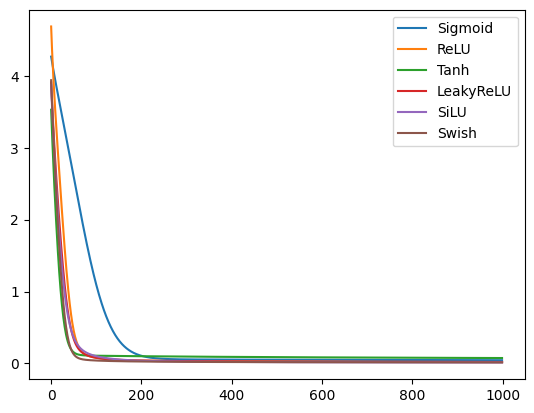

In [97]:
plot_losses(losses_b)

Mlp Batch дае більш точний прогноз та навчання та стабільне навчання

In [98]:
class MlpDropoutBatch(nn.Module):
    def __init__(
        self, 
        input_size=10,      # S-elements (вхідний шар) / ознаки
        hidden_size=32,     # A-elements (прихований/внутрішній шар)
        output_size=1,      # R-elements (виходи)
        activation="ReLU"   # функція активації елементів
    ):
        super(MlpDropoutBatch, self).__init__()
        self.activation = activators.get(activation,None)
        if self.activation is None :
            raise ValueError(f"Undefined activator '{activation}'")
        self.hidden = nn.Linear(input_size, hidden_size)
        self.batch = nn.BatchNorm1d(hidden_size)
        self.dropout = nn.Dropout(p=0.3)
        self.output = nn.Linear(hidden_size, output_size)
        

    def forward(self,x, mode='test') :
        x = self.hidden(x)
        x = self.batch(x)
        x = self.activation(x)
        if mode != "test" :
            x = self.dropout(x)
        x = self.output(x)
        return x
        

In [99]:
mlps_db = { k: MlpDropoutBatch(activation=k) for k in activators.keys() }
losses_db , predictions_db = train_models_set(mlps_db, xtrain, ytrain)
print(*zip(*(predictions_db[k][:5] for k in mlps_db.keys() ), ytest[:5]),sep='\n')
score_table(ytest, predictions_db)


(tensor([0.4636]), tensor([0.5798]), tensor([0.5102]), tensor([0.4624]), tensor([0.4101]), tensor([0.3369]), tensor([0.5157]))
(tensor([0.2602]), tensor([0.2080]), tensor([0.2909]), tensor([0.2006]), tensor([0.1944]), tensor([0.2683]), tensor([0.2556]))
(tensor([0.9487]), tensor([0.8071]), tensor([1.0840]), tensor([0.8853]), tensor([0.8173]), tensor([0.8583]), tensor([0.8399]))
(tensor([1.4500]), tensor([1.4168]), tensor([1.5461]), tensor([1.3931]), tensor([1.2800]), tensor([1.4256]), tensor([1.3304]))
(tensor([1.8315]), tensor([1.8450]), tensor([1.7491]), tensor([1.7626]), tensor([1.7368]), tensor([1.8374]), tensor([1.8622]))


|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.179621621966362|0.9698106050491333|
|ReLU|0.11824485659599304|0.994269609451294|
|Tanh|0.21535150706768036|0.9691120386123657|
|LeakyReLU|0.10879507660865784|0.9952452778816223|
|SiLU|0.09701244533061981|0.9961430430412292|
|Swish|0.09995286911725998|0.9960357546806335|

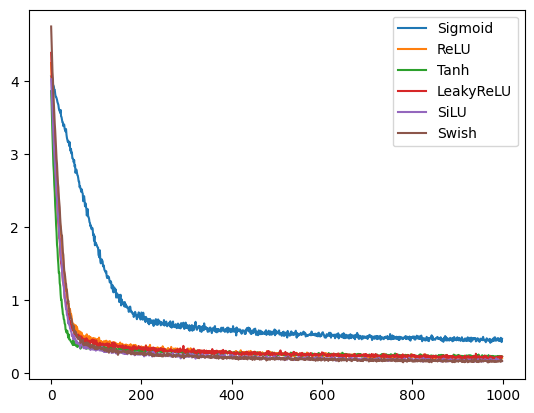

In [100]:
plot_losses(losses_db)


Завдання 4
Зробіть підсумкове порівняння всіх варіантів моделі.
Об'єднайте результати у зведену таблицю:

|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|...|...|
|ReLU + Dropout|...|...|
|ReLU + BatchNorm|...|...|
|ReLU + Dropout + BatchNorm|...|...|

- Визначте, яка комбінація дає найбільш стійке навчання.
- Сформулюйте короткий висновок (3-4 речення) у стилі технічного звіту.



In [116]:
md(f"""|Конфігурація|MAE|R²|
|-|-|-|
|ReLU|{sm.mean_absolute_error(ytest,predictions["ReLU"])}|{sm.r2_score(ytest,predictions["ReLU"])}|
|ReLU + Dropout|{sm.mean_absolute_error(ytest,predictions_d["ReLU"])}|{sm.r2_score(ytest,predictions_d["ReLU"])}|
|ReLU + BatchNorm|{sm.mean_absolute_error(ytest,predictions_b["ReLU"])}|{sm.r2_score(ytest,predictions__b["ReLU"])}|
|ReLU + Dropout + BatchNorm|{sm.mean_absolute_error(ytest,predictions_db["ReLU"])}|{sm.r2_score(ytest,predictions_db["ReLU"])}|""")



NameError: name 'predictions__b' is not defined